# Sales Data Analysis with Pandas

This notebook demonstrates data analysis on sales data using Pandas, including:
- Loading CSV data
- Data exploration and cleaning
- Grouping and aggregation
- Visualizations with charts

## 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load CSV Data

In [2]:
# Load the sales data from CSV file
df = pd.read_csv('sales_data.csv')

print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")

Data loaded successfully!
Dataset shape: (30, 6)


## 3. Explore the Dataset

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

print("\n" + "="*50 + "\n")

# Dataset information
print("Dataset Information:")
print(df.info())

print("\n" + "="*50 + "\n")

# Statistical summary
print("Statistical Summary:")
print(df.describe())

First 5 rows of the dataset:
         Date Product     Category Region  Sales  Quantity
0  2024-01-15  Laptop  Electronics  North   1200         2
1  2024-01-16   Phone  Electronics  South    800         4
2  2024-01-17    Desk    Furniture   East    350         1
3  2024-01-18   Chair    Furniture   West    150         3
4  2024-01-19  Laptop  Electronics  North   1800         3


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      30 non-null     object
 1   Product   30 non-null     object
 2   Category  30 non-null     object
 3   Region    30 non-null     object
 4   Sales     30 non-null     int64 
 5   Quantity  30 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 1.5+ KB
None


Statistical Summary:
             Sales   Quantity
count    30.000000  30.000000
mean    829.166667   3.000000
std     641.829394  

## 4. Data Cleaning

In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

print("\n" + "="*50 + "\n")

# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n" + "="*50 + "\n")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
print("Date column converted to datetime format")
print(f"\nData types:\n{df.dtypes}")

Missing values in each column:
Date        0
Product     0
Category    0
Region      0
Sales       0
Quantity    0
dtype: int64


Number of duplicate rows: 0


Date column converted to datetime format

Data types:
Date        datetime64[ns]
Product             object
Category            object
Region              object
Sales                int64
Quantity             int64
dtype: object


## 5. Group and Aggregate Sales Data

In [5]:
# Group by Category
sales_by_category = df.groupby('Category')[['Sales', 'Quantity']].sum()
print("Sales by Category:")
print(sales_by_category)

print("\n" + "="*50 + "\n")

# Group by Region
sales_by_region = df.groupby('Region')[['Sales', 'Quantity']].sum()
print("Sales by Region:")
print(sales_by_region)

print("\n" + "="*50 + "\n")

# Group by Product
sales_by_product = df.groupby('Product')[['Sales', 'Quantity']].sum().sort_values('Sales', ascending=False)
print("Sales by Product:")
print(sales_by_product)

Sales by Category:
             Sales  Quantity
Category                    
Electronics  20600        61
Furniture     4275        29


Sales by Region:
        Sales  Quantity
Region                 
East     4825        17
North    9200        27
South    6600        30
West     4250        16


Sales by Product:
         Sales  Quantity
Product                 
Laptop   12600        21
Phone     4800        24
Monitor   3200        16
Desk      1820         7
Table     1550         4
Chair      905        18


## 6. Calculate Total Sales

In [6]:
# Calculate total sales and quantities
total_sales = df['Sales'].sum()
total_quantity = df['Quantity'].sum()
average_sale = df['Sales'].mean()

print(f"Total Sales Revenue: ${total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Average Sale Amount: ${average_sale:,.2f}")

print("\n" + "="*50 + "\n")

# Sales statistics by category
print("Sales Statistics by Category:")
category_stats = df.groupby('Category')['Sales'].agg(['sum', 'mean', 'count'])
category_stats.columns = ['Total Sales', 'Average Sale', 'Number of Transactions']
print(category_stats)

Total Sales Revenue: $24,875.00
Total Quantity Sold: 90
Average Sale Amount: $829.17


Sales Statistics by Category:
             Total Sales  Average Sale  Number of Transactions
Category                                                      
Electronics        20600   1144.444444                      18
Furniture           4275    356.250000                      12


## 7. Create Visualizations

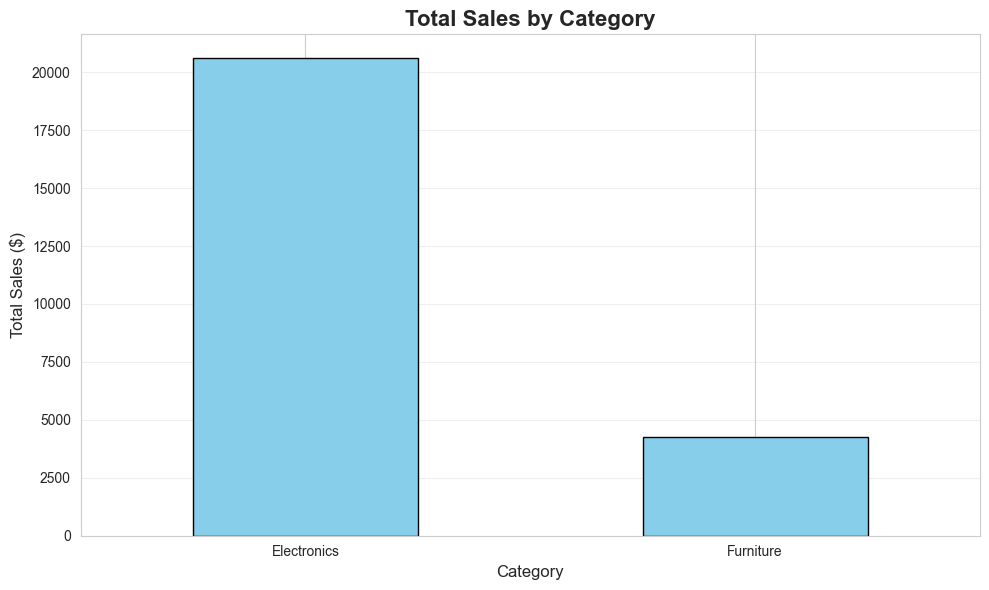

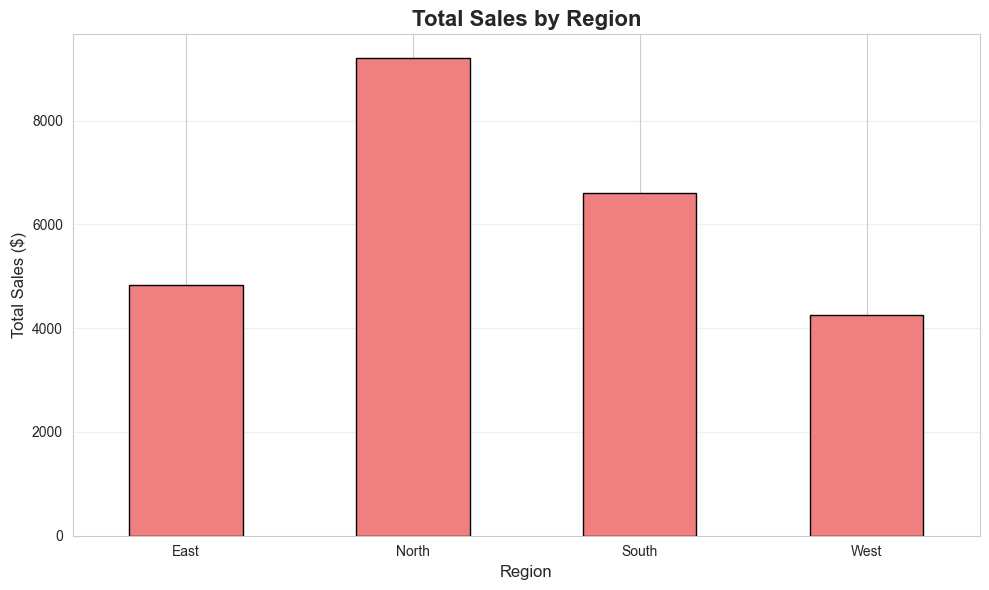

In [7]:
# Bar chart: Sales by Category
plt.figure(figsize=(10, 6))
sales_by_category['Sales'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Bar chart: Sales by Region
plt.figure(figsize=(10, 6))
sales_by_region['Sales'].plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Total Sales by Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Sales Trends Over Time

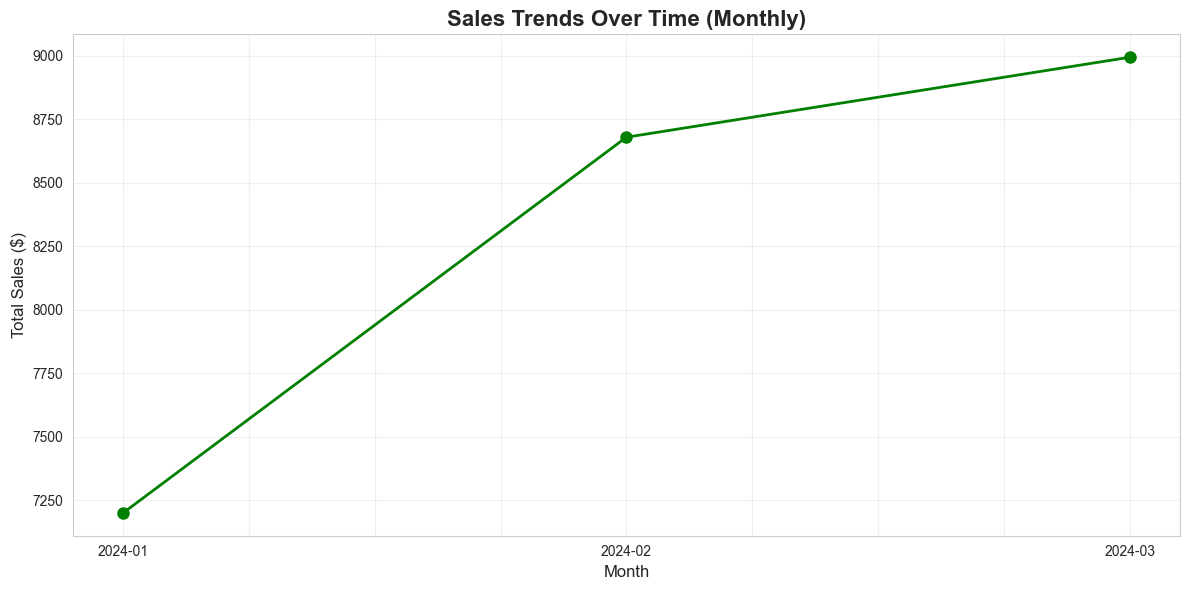


Monthly Sales:
Month
2024-01    7200
2024-02    8680
2024-03    8995
Name: Sales, dtype: int64


In [8]:
# Group by date to analyze sales trends
df['Month'] = df['Date'].dt.to_period('M')
sales_by_month = df.groupby('Month')['Sales'].sum()

# Convert Period to string for plotting
sales_by_month.index = sales_by_month.index.astype(str)

# Line plot: Sales trends over time
plt.figure(figsize=(12, 6))
sales_by_month.plot(kind='line', marker='o', color='green', linewidth=2, markersize=8)
plt.title('Sales Trends Over Time (Monthly)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMonthly Sales:")
print(sales_by_month)

## 9. Top Products Analysis

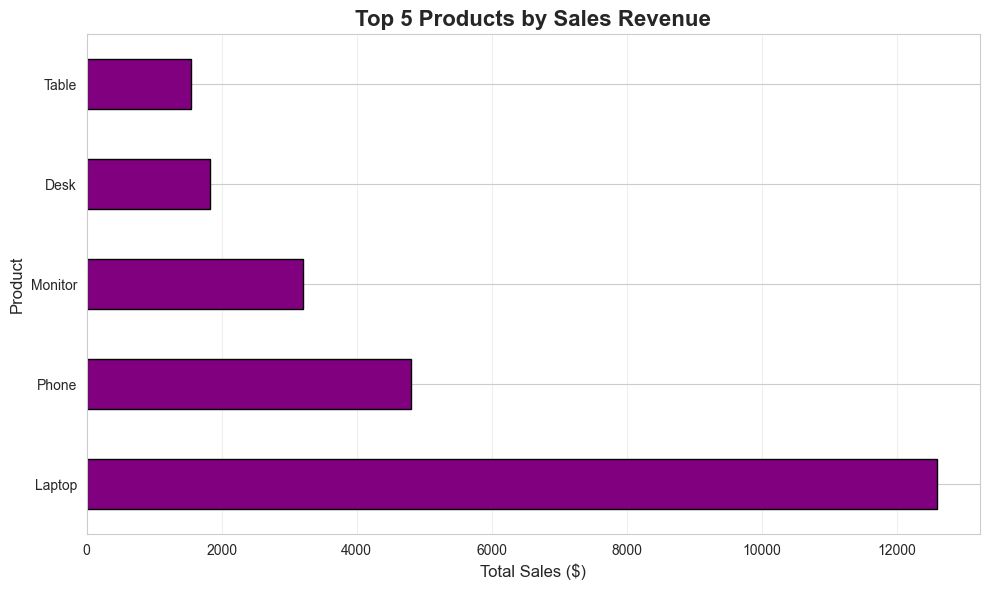


Top 5 Products by Sales:
         Sales  Quantity
Product                 
Laptop   12600        21
Phone     4800        24
Monitor   3200        16
Desk      1820         7
Table     1550         4


In [9]:
# Top 5 products by sales
top_products = sales_by_product.head(5)

# Horizontal bar chart for top products
plt.figure(figsize=(10, 6))
top_products['Sales'].plot(kind='barh', color='purple', edgecolor='black')
plt.title('Top 5 Products by Sales Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 5 Products by Sales:")
print(top_products)

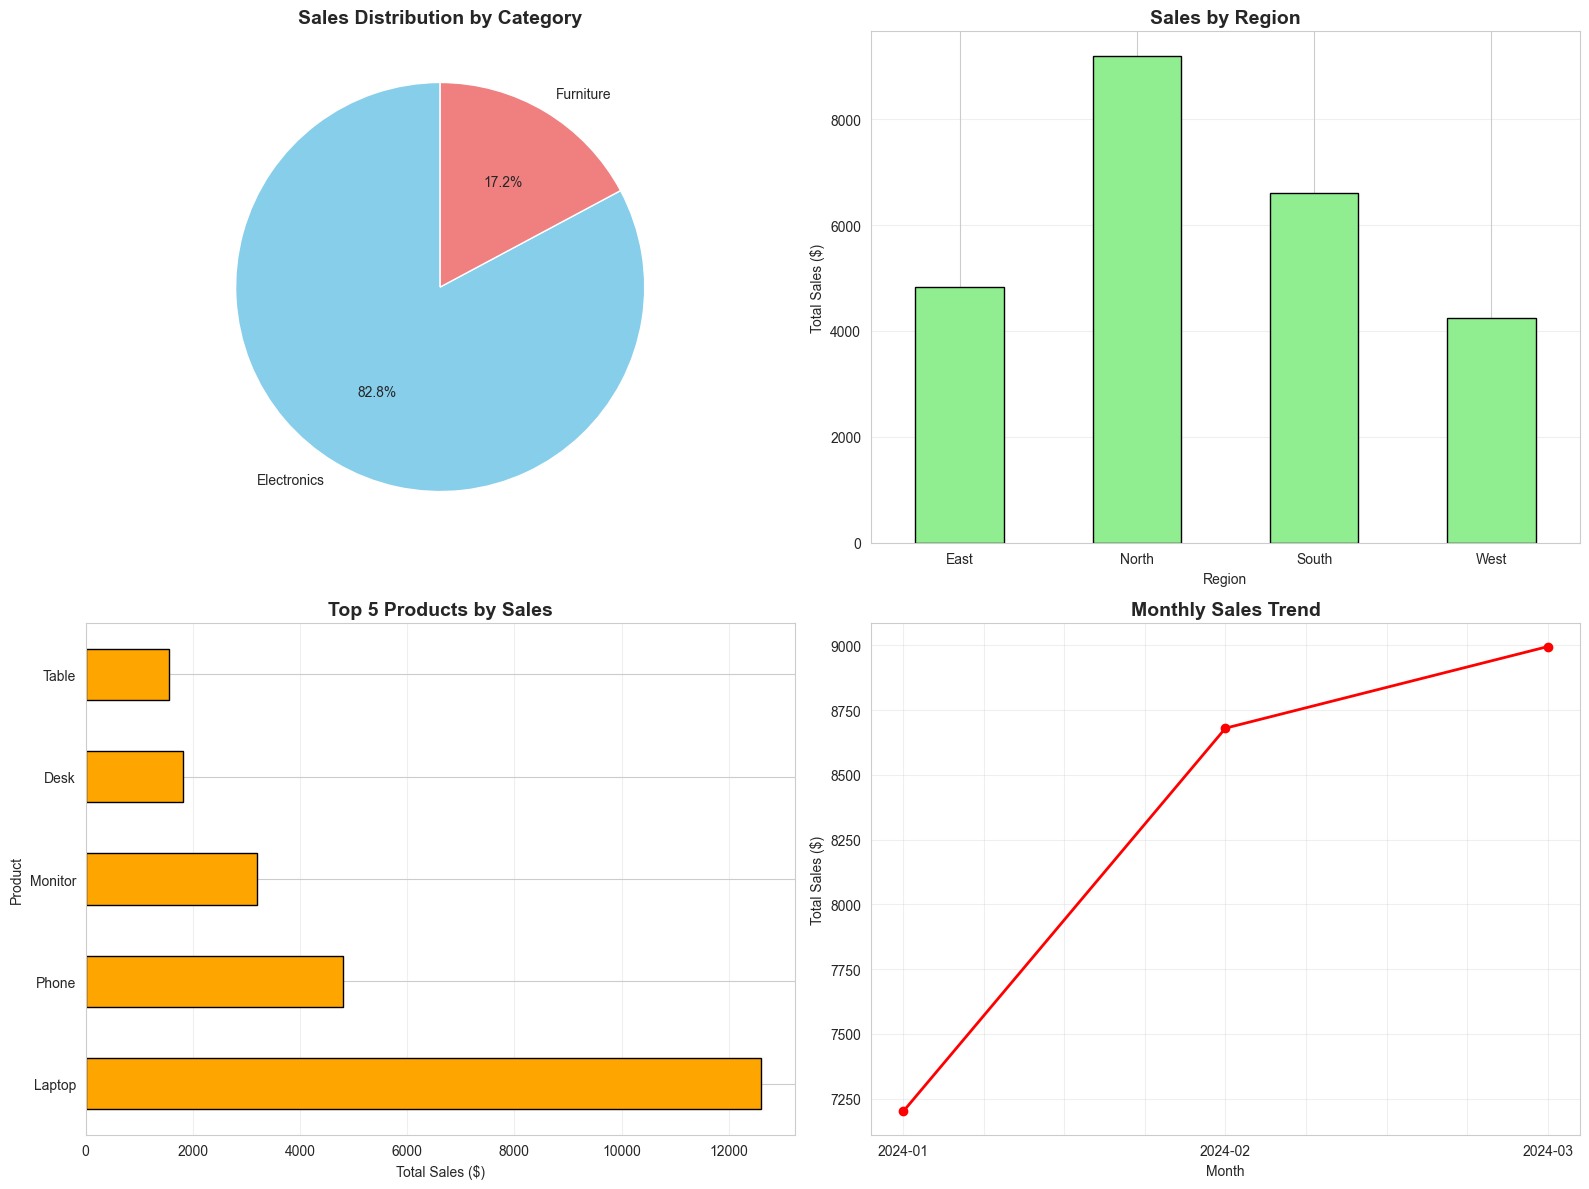


✅ Sales Data Analysis Complete!


In [10]:
# Create a comprehensive dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sales by Category (Pie Chart)
axes[0, 0].pie(sales_by_category['Sales'], labels=sales_by_category.index, autopct='%1.1f%%', 
               startangle=90, colors=['skyblue', 'lightcoral'])
axes[0, 0].set_title('Sales Distribution by Category', fontsize=14, fontweight='bold')

# 2. Sales by Region (Bar Chart)
sales_by_region['Sales'].plot(kind='bar', ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Sales by Region', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Region')
axes[0, 1].set_ylabel('Total Sales ($)')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Top Products (Horizontal Bar)
sales_by_product.head(5)['Sales'].plot(kind='barh', ax=axes[1, 0], color='orange', edgecolor='black')
axes[1, 0].set_title('Top 5 Products by Sales', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Total Sales ($)')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Monthly Sales Trend (Line Chart)
sales_by_month.plot(kind='line', ax=axes[1, 1], marker='o', color='red', linewidth=2)
axes[1, 1].set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Sales ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Sales Data Analysis Complete!")